<a href="https://colab.research.google.com/github/orcasandpandas/Data-Science-Cohort-20/blob/main/Project_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 2: Housing Price Prediction


The project should be done using Regression prediction techniques ( with feature scaling and regularization ) as covered in class.
The goal is to minimize the RMS ***percentage*** error ( root mean squared percentage error - RMSPE ) on your prediction of the house sales price.



Any of the available features can be used in the regression, but a minimum set of variables that do the job should be the ultimate goal.



Be sure to go through the whole data science process and document as such in your Jupyter notebook.



This project will have less direct "To Do" guidance and the progression through the data science process will be more individualized this time around.
We will talk about all the issues during class so you're not going to be out on a ledge with this one, I just want to move you towards performing a data science project on your own eventually.



A data dictionary file is available at AWS S3 at [Housing Data Dictionary]( https://ddc-datascience.s3.amazonaws.com/Projects/Project.2-Housing/Housing%20-%20Data%20Documentation.pdf ).

The data is available on AWS S3 at https://ddc-datascience.s3.amazonaws.com/Projects/Project.2-Housing/Data/Housing.Data.csv .


# Imports/Data Analysis

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn import datasets
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error

The standard modules of a data science notebook are utilized, with pandas processing dataframes, matplotlib making graphs, numpy working with complex arrays and sklearn providing some models.

## Dataset Overview

In [ ]:
url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.2-Housing/Data/Housing.Data.csv"


df = pd.read_csv(url)
df

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,905101070,20,RL,62.0,14299,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,7,2007,WD,Normal,115400
1,905101330,90,RL,72.0,10791,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,Shed,500,10,2006,WD,Normal,90000
2,903454090,50,RM,50.0,9000,Pave,NaN,Reg,Bnk,AllPub,...,0,NaN,NaN,NaN,0,12,2007,WD,Normal,141000
3,533244030,60,FV,68.0,7379,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,254000
4,909252020,70,RL,60.0,7200,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,4,2009,WD,Normal,155000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2632,903231070,50,RM,52.0,6240,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,Shed,400,9,2006,WD,Normal,114500
2633,906201021,80,RL,74.0,10778,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2009,WD,Normal,162000
2634,533253070,120,RL,61.0,3782,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2009,WD,Normal,211500
2635,527376100,20,RL,78.0,10140,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,8,2009,WD,Normal,165000


Quite a bit dataset, and not all features are necessarily useful!

In [ ]:
print(df.head().T.to_string())

                         0          1          2          3          4
PID              905101070  905101330  903454090  533244030  909252020
MS SubClass             20         90         50         60         70
MS Zoning               RL         RL         RM         FV         RL
Lot Frontage          62.0       72.0       50.0       68.0       60.0
Lot Area             14299      10791       9000       7379       7200
Street                Pave       Pave       Pave       Pave       Pave
Alley                  NaN        NaN        NaN        NaN        NaN
Lot Shape              Reg        Reg        Reg        IR1        Reg
Land Contour           Lvl        Lvl        Bnk        Lvl        Lvl
Utilities           AllPub     AllPub     AllPub     AllPub     AllPub
Lot Config          Inside     Inside     Inside     Inside     Inside
Land Slope             Gtl        Gtl        Gtl        Gtl        Gtl
Neighborhood        Sawyer     Sawyer     IDOTRR    Somerst      SWISU
Condit

We'll need to get some context on what things like PID and MS Zoning are.. PID stands for Parcel Identification Number, whie MS SubClass and MS Zoning indicate that we are looking at houses in Mississippi

In [ ]:
df.tail()

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
2632,903231070,50,RM,52.0,6240,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,Shed,400,9,2006,WD,Normal,114500
2633,906201021,80,RL,74.0,10778,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2009,WD,Normal,162000
2634,533253070,120,RL,61.0,3782,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2009,WD,Normal,211500
2635,527376100,20,RL,78.0,10140,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,8,2009,WD,Normal,165000
2636,528292060,60,RL,41.0,12460,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2008,WD,Normal,225000


## Stats of the dataset

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2637 entries, 0 to 2636
Data columns (total 81 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PID              2637 non-null   int64  
 1   MS SubClass      2637 non-null   int64  
 2   MS Zoning        2637 non-null   object 
 3   Lot Frontage     2188 non-null   float64
 4   Lot Area         2637 non-null   int64  
 5   Street           2637 non-null   object 
 6   Alley            180 non-null    object 
 7   Lot Shape        2637 non-null   object 
 8   Land Contour     2637 non-null   object 
 9   Utilities        2637 non-null   object 
 10  Lot Config       2637 non-null   object 
 11  Land Slope       2637 non-null   object 
 12  Neighborhood     2637 non-null   object 
 13  Condition 1      2637 non-null   object 
 14  Condition 2      2637 non-null   object 
 15  Bldg Type        2637 non-null   object 
 16  House Style      2637 non-null   object 
 17  Overall Qual  

A lot of object types!  Those will need to be dealt with later

In [ ]:
# .T transposes the dataframe so we can view all columns and their stats
analysis_df = df.describe().T
analysis_df

,count,mean,std,min,25%,50%,75%,max
PID,2637.0,7.141301e+08,1.887527e+08,526301100.0,5.284770e+08,535453040.0,9.071870e+08,1.007100e+09
MS SubClass,2637.0,5.734926e+01,4.249909e+01,20.0,2.000000e+01,50.0,7.000000e+01,1.900000e+02
Lot Frontage,2188.0,6.916682e+01,2.335678e+01,21.0,5.800000e+01,68.0,8.000000e+01,3.130000e+02
Lot Area,2637.0,1.004469e+04,6.742550e+03,1300.0,7.436000e+03,9450.0,1.152600e+04,1.646600e+05
Overall Qual,2637.0,6.097459e+00,1.411522e+00,1.0,5.000000e+00,6.0,7.000000e+00,1.000000e+01
Overall Cond,2637.0,5.569966e+00,1.118262e+00,1.0,5.000000e+00,5.0,6.000000e+00,9.000000e+00
Year Built,2637.0,1.971289e+03,3.030699e+01,1872.0,1.954000e+03,1973.0,2.001000e+03,2.010000e+03
Year Remod/Add,2637.0,1.984203e+03,2.091308e+01,1950.0,1.965000e+03,1993.0,2.004000e+03,2.010000e+03
Mas Vnr Area,2614.0,1.018879e+02,1.795782e+02,0.0,0.000000e+00,0.0,1.640000e+02,1.600000e+03
BsmtFin SF 1,2636.0,4.384412e+02,4.496023e+02,0.0,0.000000e+00,368.0,7.320000e+02,5.644000e+03


Looking at all the stats, nothing seems illogical (i.e. years are reasonable, sales prices aren't negative)

In [ ]:
print((df.isna().sum().sort_values(ascending=False)*100/len(df)).to_string())

Pool QC            99.582859
Misc Feature       96.359499
Alley              93.174061
Fence              79.977247
Mas Vnr Type       60.940463
Fireplace Qu       48.691695
Lot Frontage       17.026925
Garage Yr Blt       5.574516
Garage Cond         5.574516
Garage Qual         5.574516
Garage Finish       5.574516
Garage Type         5.498673
Bsmt Exposure       2.882063
BsmtFin Type 2      2.806219
Bsmt Cond           2.768297
Bsmt Qual           2.768297
BsmtFin Type 1      2.768297
Mas Vnr Area        0.872203
Bsmt Full Bath      0.075844
Bsmt Half Bath      0.075844
Total Bsmt SF       0.037922
BsmtFin SF 2        0.037922
Garage Area         0.037922
Garage Cars         0.037922
BsmtFin SF 1        0.037922
Bsmt Unf SF         0.037922
Land Contour        0.000000
Street              0.000000
Lot Shape           0.000000
MS SubClass         0.000000
MS Zoning           0.000000
PID                 0.000000
Lot Area            0.000000
House Style         0.000000
Bldg Type     

Some cells have a lot of nulls, though that could mean only a few houses have those features.  Still, something to look out for.

In [ ]:
# Merges our statistics dataframe with one showing percentage of empy values
analysis_df = pd.concat((analysis_df, df.isna().sum().sort_values(ascending=False)*100/len(df)), axis = 1)
# The added column is named 0 by default and has to be changed
analysis_df = analysis_df.rename(columns = {0 : "Empty Value %"})
analysis_df

,count,mean,std,min,25%,50%,75%,max,Empty Value %
PID,2637.0,7.141301e+08,1.887527e+08,526301100.0,528477010.0,535453040.0,907187010.0,1.007100e+09,0.000000
MS SubClass,2637.0,5.734926e+01,4.249909e+01,20.0,20.0,50.0,70.0,1.900000e+02,0.000000
Lot Frontage,2188.0,6.916682e+01,2.335678e+01,21.0,58.0,68.0,80.0,3.130000e+02,17.026925
Lot Area,2637.0,1.004469e+04,6.742550e+03,1300.0,7436.0,9450.0,11526.0,1.646600e+05,0.000000
Overall Qual,2637.0,6.097459e+00,1.411522e+00,1.0,5.0,6.0,7.0,1.000000e+01,0.000000
...,...,...,...,...,...,...,...,...,...
Functional,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
Kitchen Qual,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
Paved Drive,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
Sale Type,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000


It does not hurt to have the stats side by side

Woah, seems some columsn have a lot of nulls!  But not so fast.. we shouldn't necessarily remove them because things like alleys or fences are features that many homes won't have, hence it's still good to keep these variables in.

This shows that outside context is needed when working with data.



In [ ]:
# The number of unique values has to be transposed like our original stats dataframe
analysis_df = pd.concat((analysis_df,df.nunique().T), axis = 1)
analysis_df = analysis_df.rename(columns = {0 : "Unique Values"})
analysis_df.sort_values(by = "Unique Values", ascending = False)

,count,mean,std,min,25%,50%,75%,max,Empty Value %,Unique Values
PID,2637.0,7.141301e+08,1.887527e+08,526301100.0,528477010.0,535453040.0,9.071870e+08,1.007100e+09,0.000000,2637
Lot Area,2637.0,1.004469e+04,6.742550e+03,1300.0,7436.0,9450.0,1.152600e+04,1.646600e+05,0.000000,1799
Gr Liv Area,2637.0,1.496985e+03,4.952096e+02,334.0,1128.0,1441.0,1.740000e+03,5.642000e+03,0.000000,1216
Bsmt Unf SF,2636.0,5.556692e+02,4.362232e+02,0.0,218.0,464.5,7.972500e+02,2.336000e+03,0.037922,1080
1st Flr SF,2637.0,1.155506e+03,3.825975e+02,334.0,878.0,1082.0,1.380000e+03,4.692000e+03,0.000000,1022
...,...,...,...,...,...,...,...,...,...,...
Land Slope,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,3
Utilities,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,3
Alley,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,93.174061,2
Street,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,2


By looking at the amount of unique values, we can see what values may be more categorial

# Feature Selection/Exploratory Data Analysis

In [ ]:
df = df.drop(columns = ["PID"], axis = "columns")

For prediction purposes we don't really need the PID

Lets take a look at all variables that show the houses condition or quality...

A few things to note: Condition 1 and 2 are dominated by Norm (or normal) making them mostly redundant.

Kitchen Qual be considered because it has decent variance and kitchens are a large factor in house price compared to the garage or basement.

Basement Qual and Exter Qual can aso be considered; low quality square feet is redundant when overall quality or condition exists.

At the bare minimum, overall quality and condition can be kept!

## Numerical Columns

In [ ]:
# This selects only columns with data of the number type
numeric_df = df.select_dtypes(include='number')
numeric_df.describe().T

,count,mean,std,min,25%,50%,75%,max
MS SubClass,2637.0,57.349261,42.499091,20.0,20.00,50.0,70.00,190.0
Lot Frontage,2188.0,69.166819,23.356779,21.0,58.00,68.0,80.00,313.0
Lot Area,2637.0,10044.694729,6742.549521,1300.0,7436.00,9450.0,11526.00,164660.0
Overall Qual,2637.0,6.097459,1.411522,1.0,5.00,6.0,7.00,10.0
Overall Cond,2637.0,5.569966,1.118262,1.0,5.00,5.0,6.00,9.0
Year Built,2637.0,1971.288586,30.306986,1872.0,1954.00,1973.0,2001.00,2010.0
Year Remod/Add,2637.0,1984.202882,20.913077,1950.0,1965.00,1993.0,2004.00,2010.0
Mas Vnr Area,2614.0,101.887911,179.578232,0.0,0.00,0.0,164.00,1600.0
BsmtFin SF 1,2636.0,438.441199,449.602326,0.0,0.00,368.0,732.00,5644.0
BsmtFin SF 2,2636.0,51.068665,172.521803,0.0,0.00,0.0,0.00,1526.0


In [ ]:
numeric_df['Garage Yr Blt'].sort_values(ascending = False)

,Garage Yr Blt
2104,2207.0
2193,2010.0
321,2010.0
2072,2010.0
1747,2010.0
...,...
2556,NaN
2567,NaN
2603,NaN
2604,NaN


In [ ]:
numeric_df.corr()['SalePrice'].abs().sort_values(ascending = False)

,SalePrice
SalePrice,1.000000
Overall Qual,0.805016
Gr Liv Area,0.705482
Garage Cars,0.647223
Garage Area,0.633900
Total Bsmt SF,0.628669
1st Flr SF,0.618247
Year Built,0.562777
Full Bath,0.542386
Year Remod/Add,0.539932


When thinking of what features to keep, seeing which ones correlate the most with our target variable of sales price helps

I've removed numeric variables that seem both redundant or have rare appearances and have a low correlation with value

In [ ]:
pred_corr = numeric_df.drop("SalePrice", axis = 1).corr().abs()
# Sliced like a sandwich
tri_mask = np.triu(np.ones_like(pred_corr, dtype = bool), k=1)
tri_corr = pred_corr.where(tri_mask)
rank_corr = tri_corr.unstack().dropna().sort_values(ascending=False)
rank_corr

,,0
Garage Area,Garage Cars,0.892040
Garage Yr Blt,Year Built,0.831714
TotRms AbvGrd,Gr Liv Area,0.807065
1st Flr SF,Total Bsmt SF,0.782696
TotRms AbvGrd,Bedroom AbvGr,0.676025
...,...,...
Bsmt Half Bath,Mas Vnr Area,0.000873
Mas Vnr Area,MS SubClass,0.000571
Open Porch SF,Low Qual Fin SF,0.000429
3Ssn Porch,Wood Deck SF,0.000241


Lets see what variables are most closely correlated

In [ ]:
numeric_df.drop(columns = ["Garage Cars", "Garage Yr Blt"])

,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,BsmtFin SF 2,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
0,20,62.0,14299,4,3,1964,1964,0.0,513.0,144.0,...,0,0,0,0,0,0,0,7,2007,115400
1,90,72.0,10791,4,5,1967,1967,0.0,0.0,0.0,...,0,0,0,0,0,0,500,10,2006,90000
2,50,50.0,9000,6,6,1937,1950,0.0,0.0,0.0,...,0,162,0,0,126,0,0,12,2007,141000
3,60,68.0,7379,8,5,2000,2000,0.0,484.0,0.0,...,280,184,0,0,0,0,0,4,2010,254000
4,70,60.0,7200,7,9,1936,2007,0.0,350.0,210.0,...,256,0,0,0,0,0,0,4,2009,155000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2632,50,52.0,6240,6,6,1934,1950,0.0,0.0,0.0,...,112,0,0,0,0,0,400,9,2006,114500
2633,80,74.0,10778,7,6,1990,1991,0.0,460.0,286.0,...,114,36,0,0,0,0,0,7,2009,162000
2634,120,61.0,3782,8,5,1981,1981,0.0,960.0,0.0,...,133,78,0,0,0,0,0,9,2009,211500
2635,20,78.0,10140,6,5,1974,1974,174.0,0.0,0.0,...,0,0,0,0,0,0,0,8,2009,165000


## Categorical Columns

In [ ]:
cat_df = df.select_dtypes(exclude=['number'])
cat_df.head().T

,0,1,2,3,4
MS Zoning,RL,RL,RM,FV,RL
Street,Pave,Pave,Pave,Pave,Pave
Alley,NaN,NaN,NaN,NaN,NaN
Lot Shape,Reg,Reg,Reg,IR1,Reg
Land Contour,Lvl,Lvl,Bnk,Lvl,Lvl
Utilities,AllPub,AllPub,AllPub,AllPub,AllPub
Lot Config,Inside,Inside,Inside,Inside,Inside
Land Slope,Gtl,Gtl,Gtl,Gtl,Gtl
Neighborhood,Sawyer,Sawyer,IDOTRR,Somerst,SWISU
Condition 1,Feedr,Norm,Norm,Norm,Feedr


Hmm...   we don't need Misc Feature since we have its numerical value, now lets get all variables that show condition or quality since those will be ordinal...

## Ordinal Columns

In [ ]:
# Select columns with strings indicating they use a quality scale
cond_qual = [col for col in cat_df.columns if "cond" in col.lower() or "qual" in col.lower() or "qc" in col.lower() or "qu" in col.lower()]
# Condition 1 and Condition 2 columns are different and shouldn't be included
cond_qual = [col for col in cond_qual if "Condition" not in col]
cond_qual

['Exter Qual',
 'Exter Cond',
 'Bsmt Qual',
 'Bsmt Cond',
 'Heating QC',
 'Kitchen Qual',
 'Fireplace Qu',
 'Garage Qual',
 'Garage Cond',
 'Pool QC']

In [ ]:
# Gather unique values from all those columns
ordinal_df = df[cond_qual]
# Flatten those columns to get a list of unique values across all those columns
all_unique = pd.unique(ordinal_df.values.ravel())
all_unique

array(['TA', nan, 'Gd', 'Ex', 'Fa', 'Po'], dtype=object)

We now know what to encode!

In [ ]:
for col in ordinal_df:
  # For every column that's ordinal, map the variables to certain numbers
  ordinal_df[col] = ordinal_df[col].map({'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, np.nan: 0})

/tmp/ipykernel_15524/4145329650.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ordinal_df[col] = ordinal_df[col].map({'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, np.nan: 0})
/tmp/ipykernel_15524/4145329650.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ordinal_df[col] = ordinal_df[col].map({'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, np.nan: 0})
/tmp/ipykernel_15524/4145329650.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_ind

In [ ]:
cat_df = cat_df.drop(columns = cond_qual)

# This shows the percentage occurence of each value in the colums
for col in cat_df.columns:
    print(f"Variable: {col}")
    print(cat_df[col].value_counts(normalize=True))


Variable: MS Zoning
MS Zoning
RL         0.774744
RM         0.158893
FV         0.046644
C (all)    0.009480
RH         0.008722
I (all)    0.000758
A (agr)    0.000758
Name: proportion, dtype: float64
Variable: Street
Street
Pave    0.995449
Grvl    0.004551
Name: proportion, dtype: float64
Variable: Alley
Alley
Grvl    0.616667
Pave    0.383333
Name: proportion, dtype: float64
Variable: Lot Shape
Lot Shape
Reg    0.630262
IR1    0.339401
IR2    0.024649
IR3    0.005688
Name: proportion, dtype: float64
Variable: Land Contour
Land Contour
Lvl    0.896852
HLS    0.042093
Bnk    0.040197
Low    0.020857
Name: proportion, dtype: float64
Variable: Utilities
Utilities
AllPub    0.998862
NoSewr    0.000758
NoSeWa    0.000379
Name: proportion, dtype: float64
Variable: Lot Config
Lot Config
Inside     0.729617
Corner     0.174061
CulDSac    0.060675
FR2        0.030717
FR3        0.004930
Name: proportion, dtype: float64
Variable: Land Slope
Land Slope
Gtl    0.952218
Mod    0.042473
Sev    0

In [ ]:
threshold = 0.80

# Drop all columns where one value occurs more than 80% of the time
to_drop = [
    col for col in cat_df.columns
    if cat_df[col].value_counts(normalize=True).values[0] > threshold
]

cat_df = cat_df.drop(columns = to_drop)
cat_df



,MS Zoning,Alley,Lot Shape,Lot Config,Neighborhood,House Style,Roof Style,Exterior 1st,Exterior 2nd,Mas Vnr Type,Foundation,Bsmt Exposure,BsmtFin Type 1,Garage Type,Garage Finish,Fence
0,RL,NaN,Reg,Inside,Sawyer,1Story,Gable,HdBoard,HdBoard,NaN,CBlock,No,Rec,Detchd,Unf,MnPrv
1,RL,NaN,Reg,Inside,Sawyer,1Story,Gable,MetalSd,MetalSd,NaN,Slab,NaN,NaN,CarPort,Unf,NaN
2,RM,NaN,Reg,Inside,IDOTRR,1.5Fin,Gable,Wd Sdng,Wd Sdng,NaN,PConc,No,Unf,Detchd,Unf,NaN
3,FV,NaN,IR1,Inside,Somerst,2Story,Gable,VinylSd,VinylSd,NaN,PConc,No,GLQ,Attchd,RFn,NaN
4,RL,NaN,Reg,Inside,SWISU,2Story,Gable,Wd Sdng,Wd Sdng,NaN,PConc,No,ALQ,Detchd,RFn,MnPrv
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2632,RM,NaN,Reg,Inside,BrkSide,1.5Fin,Gable,Wd Sdng,Wd Sdng,NaN,PConc,No,Unf,Detchd,Unf,MnPrv
2633,RL,NaN,IR1,Inside,SawyerW,SLvl,Gable,HdBoard,HdBoard,NaN,PConc,No,GLQ,Attchd,Unf,NaN
2634,RL,NaN,IR1,CulDSac,Greens,1Story,Gable,Wd Sdng,Plywood,NaN,CBlock,Gd,GLQ,Attchd,Fin,NaN
2635,RL,NaN,Reg,Inside,NWAmes,1Story,Hip,HdBoard,HdBoard,BrkFace,CBlock,No,Unf,Attchd,RFn,MnPrv


From a brief glance, it seems Neighborhood is really the only
relevant variable, as thats what is highly considered in house purchases

In [ ]:
cat_df = cat_df[["Neighborhood"]]

In [ ]:
# 1. Get the list of neighborhoods that are > 5%
counts = cat_df['Neighborhood'].value_counts(normalize=True)
big_neighborhoods = counts[counts >= 0.05].index

# 2. If it's not in the big list, rename it to 'Other'
cat_df['Neighborhood'] = cat_df['Neighborhood'].apply(lambda x: x if x in big_neighborhoods else 'Other')

# 3. One-Hot Encode (This will only create 9 columns now!)
cat_df = pd.get_dummies(cat_df, columns=['Neighborhood'], prefix='Nbhd')
cat_df

/tmp/ipykernel_15524/2575638790.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cat_df['Neighborhood'] = cat_df['Neighborhood'].apply(lambda x: x if x in big_neighborhoods else 'Other')


,Nbhd_CollgCr,Nbhd_Edwards,Nbhd_Gilbert,Nbhd_NAmes,Nbhd_NridgHt,Nbhd_OldTown,Nbhd_Other,Nbhd_Sawyer,Nbhd_Somerst
0,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,True,False
2,False,False,False,False,False,False,True,False,False
3,False,False,False,False,False,False,False,False,True
4,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...
2632,False,False,False,False,False,False,True,False,False
2633,False,False,False,False,False,False,True,False,False
2634,False,False,False,False,False,False,True,False,False
2635,False,False,False,False,False,False,True,False,False


We'll hot encode the neighbor column, and only neighborhoods that are frequent enough.




In [ ]:
df = pd.concat([ordinal_df, cat_df, numeric_df], axis=1)


Time to reunite all our dataframes

In [ ]:
df

,Exter Qual,Exter Cond,Bsmt Qual,Bsmt Cond,Heating QC,Kitchen Qual,Fireplace Qu,Garage Qual,Garage Cond,Pool QC,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
0,3,3,3,3,3,3,0,3,3,0,...,0,0,0,0,0,0,0,7,2007,115400
1,3,3,0,0,3,3,0,3,3,0,...,0,0,0,0,0,0,500,10,2006,90000
2,3,4,3,3,3,4,4,3,3,0,...,0,162,0,0,126,0,0,12,2007,141000
3,4,3,4,3,5,4,3,3,3,0,...,280,184,0,0,0,0,0,4,2010,254000
4,4,4,4,4,5,4,0,3,3,0,...,256,0,0,0,0,0,0,4,2009,155000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2632,3,3,3,3,3,3,4,3,3,0,...,112,0,0,0,0,0,400,9,2006,114500
2633,4,3,4,3,4,4,0,3,3,0,...,114,36,0,0,0,0,0,7,2009,162000
2634,4,3,4,3,3,4,3,3,3,0,...,133,78,0,0,0,0,0,9,2009,211500
2635,3,3,4,3,3,3,3,3,3,0,...,0,0,0,0,0,0,0,8,2009,165000


## Data Cleaning

In [ ]:
df.isna().sum().sort_values(ascending=False)*100/len(df)


,0
Lot Frontage,17.026925
Garage Yr Blt,5.574516
Mas Vnr Area,0.872203
Bsmt Half Bath,0.075844
Bsmt Full Bath,0.075844
Bsmt Unf SF,0.037922
BsmtFin SF 2,0.037922
Total Bsmt SF,0.037922
BsmtFin SF 1,0.037922
Garage Cars,0.037922


There are some null values that we need to get rid of

In [ ]:
df = df.fillna(0)

Here a simple imputer is used which replaces NaN values with the mean of that column.

In [ ]:
df.isna().sum().sort_values(ascending=False)*100/len(df)


,0
Exter Qual,0.0
Exter Cond,0.0
Bsmt Qual,0.0
Bsmt Cond,0.0
Heating QC,0.0
Kitchen Qual,0.0
Fireplace Qu,0.0
Garage Qual,0.0
Garage Cond,0.0
Pool QC,0.0


## Plotting all variables

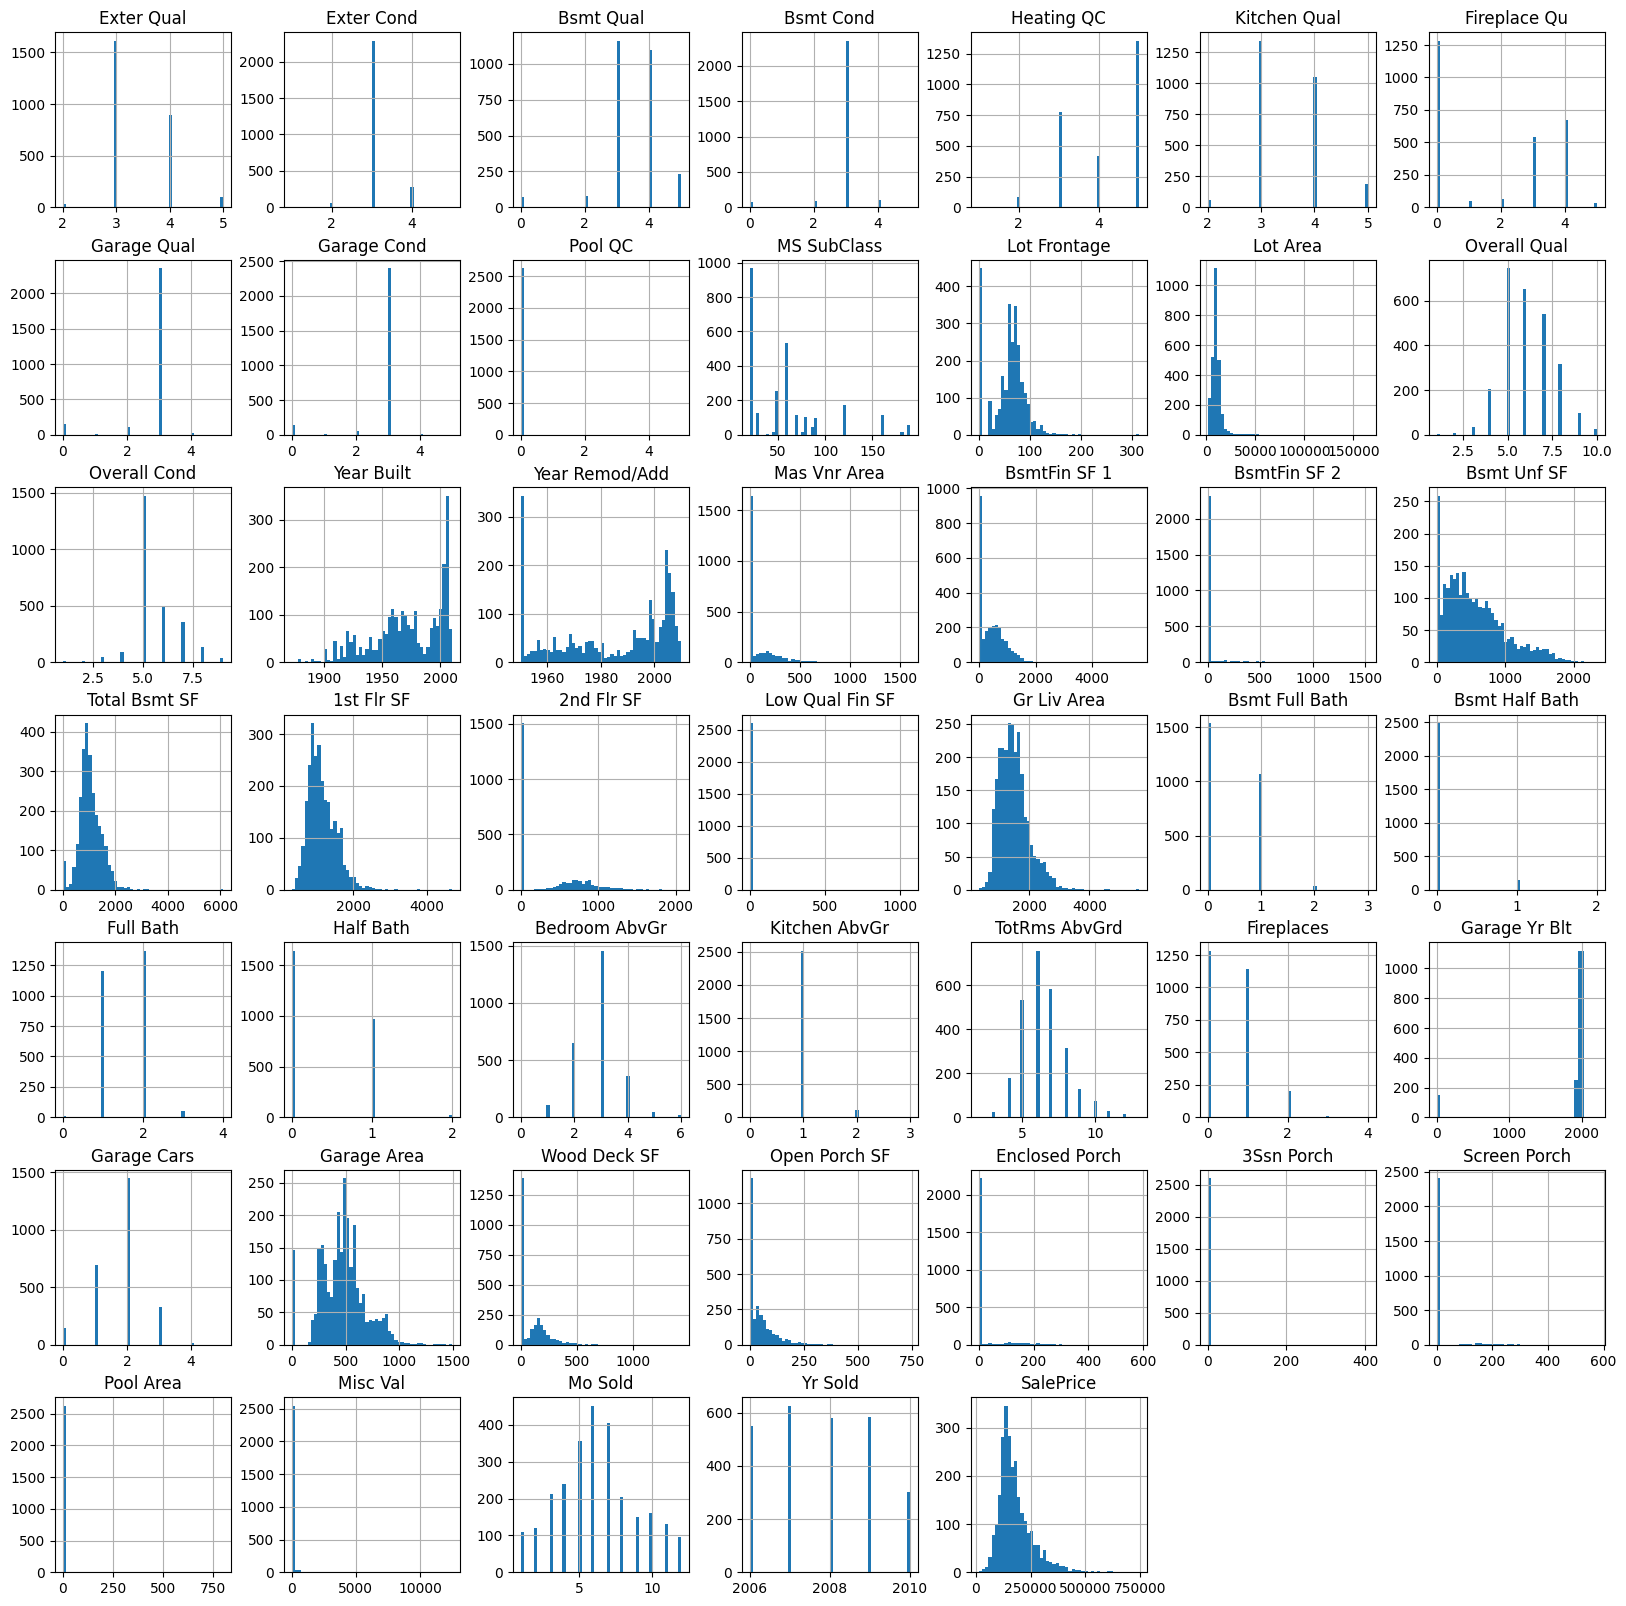

In [ ]:
df.hist(figsize=(20, 20), bins=50)
plt.show()

If we plot all variables, we can see a few have a roughly similar distribution to our target variable.

## Separating Target and Predictors

In [ ]:
# Target Variables
y = df['SalePrice'].copy()

# Predictors
X = df.drop("SalePrice", axis = 1).copy()

# Processing/Linear Regression

## Training and testing set

In [ ]:
# Split into a training and testing set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=4)

In [ ]:
model = LinearRegression()
fitted = model.fit(X_train, y_train)

( fitted.intercept_, fitted.coef_ )


(np.float64(2159276.829782238),
 array([ 1.09272076e+04,  1.19683135e+03,  8.64960731e+03, -6.61337794e+03,
         1.25255659e+03,  8.97375428e+03,  1.01469821e+03,  2.31987176e+03,
        -1.09492073e+02,  2.98042023e+03, -6.68536077e+03, -1.09360277e+04,
        -6.72676722e+03, -4.80987553e+03,  2.70530615e+04, -6.28412822e+03,
         9.48469892e+02,  4.24352219e+02,  7.01627585e+03, -1.70884776e+02,
         3.79713021e+01,  3.75493884e-01,  1.25855997e+04,  5.08292362e+03,
         2.20360488e+02, -4.17100025e+01,  2.37673313e+01,  9.20710133e+00,
         4.17522066e+00, -6.81360971e+00,  6.56871228e+00,  2.25799035e+01,
         1.60083645e+01, -5.35374605e+00,  3.32345220e+01,  6.02786992e+03,
         1.46270815e+02,  1.35695773e+03,  4.22243712e+02, -4.75492885e+03,
        -8.81251663e+03,  2.09500186e+03,  1.31933593e+03, -1.24337300e+01,
         9.60714640e+03,  3.75098423e+00,  1.45089938e+01, -3.09383947e+01,
         1.05111508e+01, -8.18256308e+00,  4.33663048e+0

We now fit a linear regression model to our data

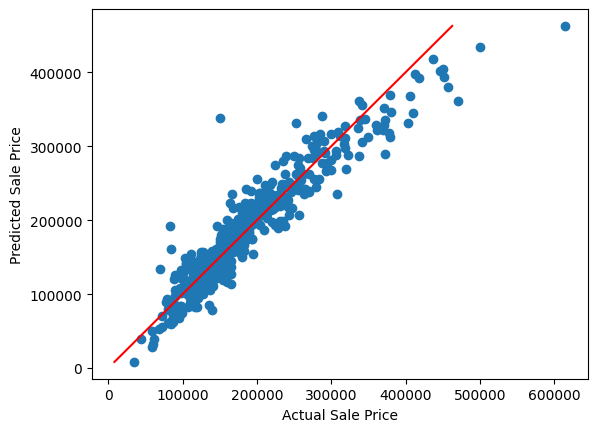

In [ ]:
y_pred = fitted.predict(X_test)
plt.scatter(y_test, y_pred)
plt.plot([min(y_pred), max(y_pred)],[min(y_pred), max(y_pred)], c='red')
plt.xlabel('Actual Sale Price')
plt.ylabel('Predicted Sale Price') ;

Here's the plot of predictions vs the actual sale price.  Seems the actual sale price has a few outliers.

In [ ]:
rmse = mean_squared_error(y_test, y_pred)**0.5
rmspe = (np.sqrt(np.mean(np.square((y_test - y_pred) / y_test)))) * 100
print(f"RMSE: {rmse}")
print(f"RMPSE: {rmspe}")

RMSE: 26111.26487940138
RMPSE: 16.778910272454635


Still, an RMSE of 26k is not bad compared to an average house price of around 180k.

## Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size = 0.2, random_state=4)

Lets scale the variables for further testing

In [ ]:
model = LinearRegression()
fitted = model.fit(X_train, y_train)

( fitted.intercept_, fitted.coef_ )


(np.float64(179910.37658100517),
 array([ 6350.02843482,   444.7471523 ,  7830.88301589, -3792.68744896,
         1201.42627932,  5912.06698262,  1826.74010587,  1674.6117946 ,
          -78.68875268,   744.08722907, -1722.02237269, -2500.38029281,
        -1391.90867448, -1470.31713964,  6427.74491431, -1538.22167638,
          801.45121584,   250.02369294,  1847.1135115 , -7261.07048692,
         1275.4756541 ,  2531.30601409, 17761.48456716,  5682.96006427,
         6677.19588503,  -872.11907101,  4254.59103319,  4528.53798741,
          869.61584075, -2593.7661701 ,  2451.66859123,  9915.6549514 ,
         8275.2643358 ,   -90.57078327, 14800.41284405,  3165.08526187,
           35.10477233,   746.39715233,   212.60564109, -3899.65023203,
        -1878.40561403,  3285.05732098,   858.79351072, -5651.45689837,
         7311.63961479,   798.71101205,  1841.23778731, -2059.00309898,
          642.92544373,  -189.47713482,  2418.67641765, -1940.46985735,
          233.05823594,   188.6

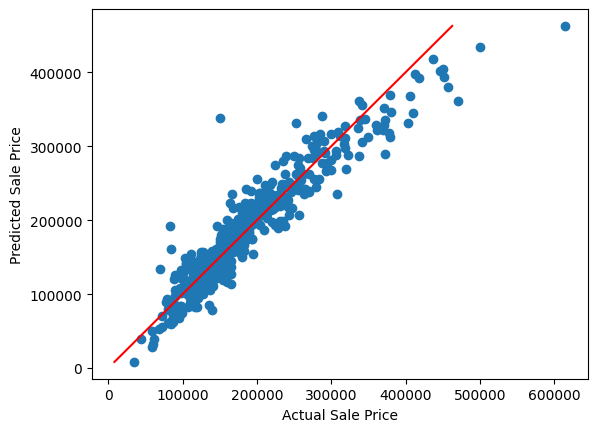

In [ ]:
y_pred = fitted.predict(X_test)
plt.scatter(y_test, y_pred)
plt.plot([min(y_pred), max(y_pred)],[min(y_pred), max(y_pred)], c='red')
plt.xlabel('Actual Sale Price')
plt.ylabel('Predicted Sale Price') ;

Analysis and Conclusion

In [ ]:
rmse = mean_squared_error(y_test, y_pred)**0.5
rmspe = (np.sqrt(np.mean(np.square((y_test - y_pred) / y_test)))) * 100
print(f"RMSE: {rmse}")
print(f"RMPSE: {rmspe}")

RMSE: 26111.26487940001
RMPSE: 16.778910272458255


The RMSE is the same, but our variables will be scaled better if we want to do things like regularization

## Lasso

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso


alpha = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

# Create empty list to hold results
results_alpha = []

for i in alpha:
  # Train the model
  my_fit_lasso = Lasso(alpha = i, tol = .01, max_iter=100_000) # Looping through alpha
  my_fit_lasso.fit(X_train, y_train)

  # Calculate CV RMSE
  results = cross_val_score(
      my_fit_lasso,
      X_scaled,
      y,
      scoring='neg_root_mean_squared_error',
      cv = 10
  )
  rmse = abs(results.mean())
  results_alpha.append(rmse)

results_df = pd.DataFrame({'Alpha': alpha, 'RMSE': results_alpha})
print(results_df.sort_values(by=['RMSE']))

The RMSE values are actually all higher here

## Ridge

In [ ]:
alph = [1e-15, 1e-10, 1e-8, 1e-4, 1e-3, 1e-2, 1e-1, 1, 2, 3, 4, 5, 10, 20, 30, 50]

# Create empty list to hold results
results_alpha = []

for i in alph:
  # Train the model
  my_fit_rr = Ridge(alpha = i) # Looping through alpha
  my_fit_rr.fit(X_train, y_train)

  # Calculate CV RMSE
  results = cross_val_score(
      my_fit_rr,
      X_scaled,
      y,
      scoring='neg_root_mean_squared_error',
      cv = 10
      )
  rmse = abs(results.mean())
  results_alpha.append(rmse)

results_df = pd.DataFrame({'Alpha': alph, 'RMSE': results_alpha})
print(results_df.sort_values(by=['RMSE']))

This also has higher RMSE values.

# Residual Analysis

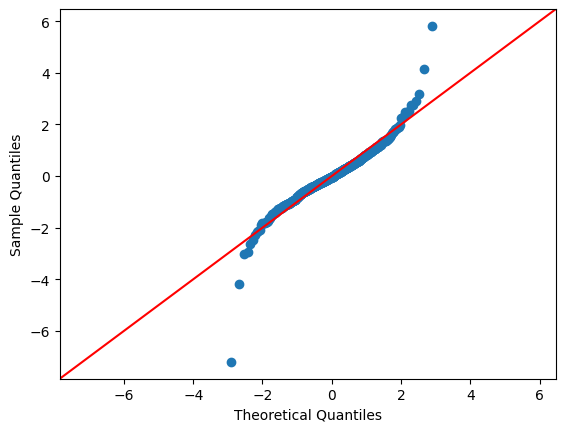

In [ ]:
import statsmodels.api as sm

res = y_test - y_pred
sm.qqplot(res, fit=True, line="45") ;

Looking at the residual analysis, it seems there are some blindspots at the high and low end of housing.  For the full picture, it seems linear regression may not be the best choice!  It's clear that our correlations resemble an exponential function rather than a linear one.  Still, the vast majority of the data points do fall on the red line

## Log Scaling

In [ ]:
# 1. Transform the target to Log scale
y_train_log = np.log(y_train)
y_test_log = np.log(y_test)

# 2. Fit the model on the log data
model_log = LinearRegression()
model_log.fit(X_train, y_train_log)

# 3. Predict
y_pred_log = model_log.predict(X_test)

# 4. Undo the logarithmic transformation on the prediction
y_pred_dollars = np.exp(y_pred_log)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_dollars))

rmspe = (np.sqrt(np.mean(np.square((y_test - y_pred_dollars) / y_test)))) * 100
print(f"RMSE: {rmse}")
print(f"RMPSE: {rmspe}")

RMSE: 25437.05253557842
RMPSE: 14.045591921243203


We can try converting the target variables logarithmically to cancel out the right skew, and the RMSE is indeed lowered

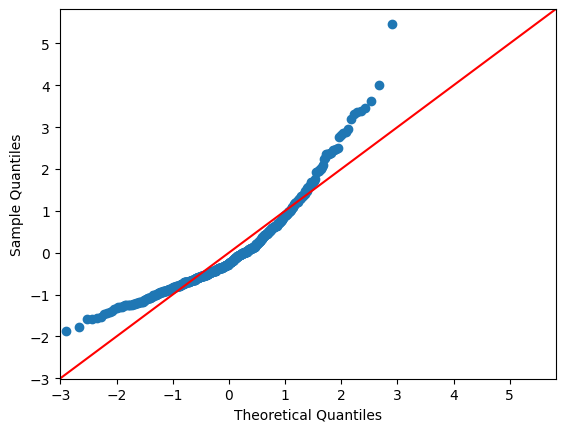

In [ ]:
res = y_test - y_pred_log
sm.qqplot(res, fit=True, line="45") ;